In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch
torch.cuda.is_available()

True

In [4]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math

In [5]:
def get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps: int,
        num_training_steps: int,
        num_cycles: float = 0.5,
        min_lr_ratio: float = 0.0,
):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return current_step / max(1, num_warmup_steps)
        
        progress = (current_step - num_warmup_steps) / max(1, num_training_steps - num_warmup_steps)
        progress = min(progress, 1.0)
        cosine_decay = 0.5 * (1.0 + math.cos(math.pi * num_cycles * 2.0 * progress))
        return max(min_lr_ratio, cosine_decay)

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [6]:
class ModelNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.ffn = nn.Linear(5, 1)

    def forward(self, X):
        return self.ffn(X)

class MockDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        x, y = self.data[idx]
        return x, y

def mock_collate_fn(batch):
    # batch is a list of (X, y) tuples, e.g.
    # [([1,2,3,4,5], [1]), ([2,3,4,5,6], [2]), ...]
    X_batch, y_batch = zip(*batch)  # unzips into two tuples of lists

    X_tensor = torch.tensor(X_batch, dtype=torch.float32)  # shape: (batch_size, 5)
    y_tensor = torch.tensor(y_batch, dtype=torch.float32)  # shape: (batch_size, 1)

    return X_tensor, y_tensor

In [14]:
import random

def generate_regression_sample(seq_len=5, noise_std=0.5):
    X = [random.uniform(0, 10) for _ in range(seq_len)]
    true_y = sum(X) / len(X)                     # target: mean of the sequence -- linear, so ModelNetwork CAN fit it exactly
    noisy_y = true_y + random.gauss(0, noise_std)  # ...except for this -- irreducible noise the model can't fit away
    return X, [noisy_y]

def generate_regression_dataset(n_samples=200, seq_len=5, noise_std=0.5):
    return [generate_regression_sample(seq_len, noise_std) for _ in range(n_samples)]


In [15]:
from torch.utils.data import random_split   # not yet imported in this notebook

samples = generate_regression_dataset(n_samples=200, seq_len=5, noise_std=0.5)
dataset = MockDataset(data=samples)

n_total = len(dataset)
n_train = int(n_total * 0.7)
n_val = int(n_total * 0.15)
n_test = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(55)
)

len(train_set), len(val_set), len(test_set)


(140, 30, 30)

In [16]:
BATCH_SIZE = 16
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, collate_fn=mock_collate_fn)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mock_collate_fn)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=mock_collate_fn)


In [ ]:
# samples = [
#     # X, y
#     ([1, 2, 3, 4, 5], [1]),
#     ([2, 3, 4, 5, 6], [2]),
#     ([3, 4, 5, 6, 7], [3]),
#     ([4, 5, 6, 7, 8], [4]),
#     ([5, 6, 7, 8, 9], [5]),
# ]
# dataset = MockDataset(data=samples)
# train_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=mock_collate_fn)

In [17]:
x, y = zip(*(
    dataset[0],
    dataset[1]
))
x, y

(([7.850668136965879,
   1.7965676776916928,
   4.130678555992942,
   3.0867430280845065,
   1.7625867453163213],
  [5.187223558072422,
   7.366797433135737,
   2.8990115215636623,
   6.188915661859536,
   7.676439840309564]),
 ([4.0728166224746944], [5.678882121710167]))

In [18]:
3e-4

0.0003

In [19]:
# model = ModelNetwork()
# # follow GPT
# betas = (0.9, 0.98) # b1, b2
# # the Karpathy constant (Andrej Karpathy tweeted that 3e-4 is "the best learning rate for Adam, hands down"
# lr = 3e-4
# weight_decay = 0.1
# optimizer = torch.optim.AdamW(
#     model.parameters(), 
#     lr=lr, 
#     betas=betas, 
#     weight_decay=weight_decay
# )

# num_epochs = 100
# num_training_steps = num_epochs * len(train_loader)
# num_warmup_steps = int(0.05 * num_training_steps)

# scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps)

# for epoch in range(num_epochs):
#     model.train()
#     for X, y_true in train_loader:
#         optimizer.zero_grad()
#         y_pred = model(X)
#         loss = F.mse_loss(y_true, y_pred)
#         loss.backward()
#         optimizer.step()
#         scheduler.step()

In [20]:
# num_epochs, num_training_steps, num_warmup_steps

In [21]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False

def save_checkpoint(path, model, optimizer, scheduler, epoch, val_loss):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "val_loss": val_loss,
    }, path)

def evaluate(model, loader):
    was_training = model.training
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X, y in loader:
            loss = F.mse_loss(y, model(X))
            total_loss += loss.item()
    if was_training:
        model.train()
    return total_loss / len(loader)


In [22]:
model = ModelNetwork()
betas = (0.9, 0.98)
lr = 3e-4
weight_decay = 0.1
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=betas, weight_decay=weight_decay)

num_epochs = 100
num_training_steps = num_epochs * len(train_loader)
num_warmup_steps = int(0.05 * num_training_steps)
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps)

early_stopper = EarlyStopping(patience=10)
best_path = "best_toy_model.pt"

lr_history, train_loss_history, val_loss_history = [], [], []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for X, y_true in train_loader:
        optimizer.zero_grad()
        y_pred = model(X)
        loss = F.mse_loss(y_true, y_pred)
        loss.backward()
        optimizer.step()
        scheduler.step()

        lr_history.append(scheduler.get_last_lr()[0])
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    val_loss = evaluate(model, val_loader)
    train_loss_history.append(avg_train_loss)
    val_loss_history.append(val_loss)

    improved = early_stopper.step(val_loss)
    if improved:
        save_checkpoint(best_path, model, optimizer, scheduler, epoch, val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, train_loss={avg_train_loss:.4f}, val_loss={val_loss:.4f}")

    if early_stopper.should_stop:
        print(f"Early stopping at epoch {epoch+1} (best val_loss={early_stopper.best_loss:.4f})")
        break

print(f"Steps actually taken: {len(lr_history)} / {num_training_steps} planned")


Epoch 10, train_loss=31.5496, val_loss=36.3108
Epoch 20, train_loss=24.9360, val_loss=29.1433
Epoch 30, train_loss=19.3297, val_loss=23.4332
Epoch 40, train_loss=15.3395, val_loss=19.1163
Epoch 50, train_loss=12.7248, val_loss=16.0475
Epoch 60, train_loss=10.6746, val_loss=13.9865
Epoch 70, train_loss=9.7097, val_loss=12.7361
Epoch 80, train_loss=9.0204, val_loss=12.0804
Epoch 90, train_loss=8.8437, val_loss=11.8340
Epoch 100, train_loss=8.7339, val_loss=11.7977
Steps actually taken: 900 / 900 planned


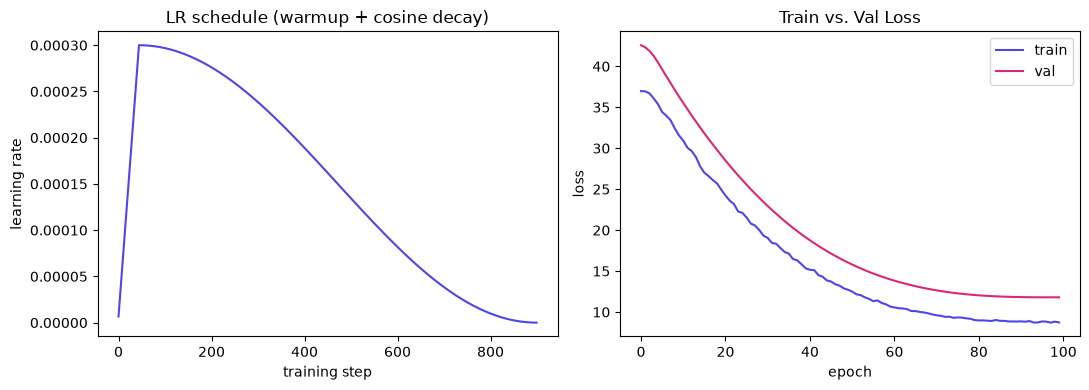

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(lr_history, color="#4f46e5")
axes[0].set_xlabel("training step")
axes[0].set_ylabel("learning rate")
axes[0].set_title("LR schedule (warmup + cosine decay)")

axes[1].plot(train_loss_history, label="train", color="#4f46e5")
axes[1].plot(val_loss_history, label="val", color="#db2777")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Train vs. Val Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for X, y in test_loader:
        y_pred = model(X)
        all_preds.append(y_pred)
        all_true.append(y)

all_preds = torch.cat(all_preds, dim=0)
all_true = torch.cat(all_true, dim=0)

# residuals = all_preds - all_true
# convention
residuals = all_true - all_preds

print(f"Residual mean: {residuals.mean().item():.4f}")
print(f"Residual std:  {residuals.std().item():.4f}")


Residual mean: 1.8151
Residual std:  2.0923


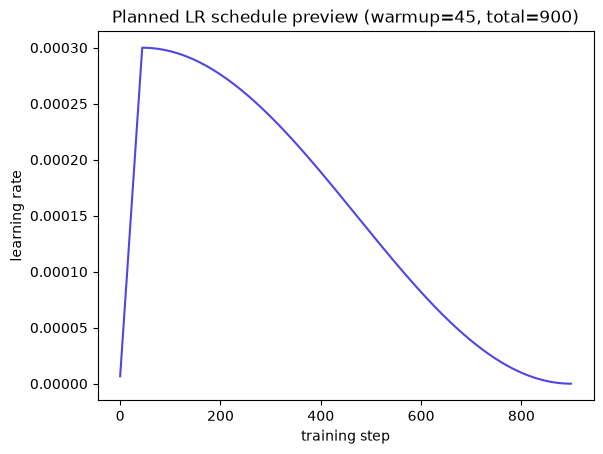

In [26]:
import torch
import matplotlib.pyplot as plt

# a dummy parameter just to give the optimizer something to attach to -- no real training happens
dummy_param = torch.nn.Parameter(torch.zeros(1))
dummy_optimizer = torch.optim.AdamW([dummy_param], lr=lr)

num_epochs_preview = 100
num_training_steps_preview = num_epochs_preview * len(train_loader)
num_warmup_steps_preview = int(0.05 * num_training_steps_preview)

preview_scheduler = get_cosine_schedule_with_warmup(
    dummy_optimizer, num_warmup_steps_preview, num_training_steps_preview
)

preview_lr_history = []
for step in range(num_training_steps_preview):
    dummy_optimizer.step()          # no gradients exist, so this is a no-op update -- just avoids a scheduler warning
    preview_scheduler.step()
    preview_lr_history.append(preview_scheduler.get_last_lr()[0])

plt.plot(preview_lr_history, color="#4f46e5")
plt.xlabel("training step")
plt.ylabel("learning rate")
plt.title(f"Planned LR schedule preview (warmup={num_warmup_steps_preview}, total={num_training_steps_preview})")
plt.show()


In [28]:
num_warmup_steps_preview

45